# 🏦 Loan Default Prediction — Exploratory Data Analysis

**Objective:** Understand the dataset, uncover patterns, identify data quality issues, and prepare insights for feature engineering and model development.

**Dataset:** 121,856 loan applications with 39 features and binary target `Default` (1 = defaulted, 0 = repaid).

---
### Contents
1. Setup & Data Loading
2. Dataset Overview
3. Target Variable Analysis (Class Imbalance)
4. Missing Value Analysis
5. Numerical Feature Analysis
6. Categorical Feature Analysis
7. Outlier Detection
8. Feature Correlation Analysis
9. Feature vs Target Relationship
10. Key Findings & Feature Engineering Plan

In [3]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries loaded ✅')

Libraries loaded ✅


In [4]:
# ── 2. Load Data ──────────────────────────────────────────────────────────────
df = pd.read_csv('data/Dataset.csv', low_memory=False)
data_dict = pd.read_csv('data/Data_Dictionary.csv')

# Coerce known numeric columns
numeric_mixed = [
    'Client_Income', 'Credit_Amount', 'Loan_Annuity',
    'Population_Region_Relative', 'Age_Days', 'Employed_Days',
    'Registration_Days', 'ID_Days', 'Score_Source_3'
]
for col in numeric_mixed:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head(3)

Dataset shape: (121856, 40)
Rows: 121,856 | Columns: 40


,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,Client_Income_Type,Client_Education,Client_Marital_Status,Client_Gender,Loan_Contract_Type,Client_Housing_Type,Population_Region_Relative,Age_Days,Employed_Days,Registration_Days,ID_Days,Own_House_Age,Mobile_Tag,Homephone_Tag,Workphone_Working,Client_Occupation,Client_Family_Members,Cleint_City_Rating,Application_Process_Day,Application_Process_Hour,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
0,12142509,6750.0000,0.0000,0.0000,1.0000,0.0000,0.0000,61190.5500,3416.8500,Alone,Commercial,Secondary,M,Male,CL,Home,0.0287,13957.0000,1062.0000,6123.0000,383.0000,NaN,1,1,0,Sales,2.0000,2.0000,6.0000,17.0000,Yes,Yes,Self-employed,0.5681,0.4788,NaN,0.0186,63.0000,NaN,0
1,12138936,20250.0000,1.0000,0.0000,1.0000,NaN,0.0000,15282.0000,1826.5500,Alone,Service,Graduation,M,Male,CL,Home,0.0086,14162.0000,4129.0000,7833.0000,21.0000,0.0000,1,0,1,NaN,2.0000,2.0000,3.0000,10.0000,Yes,Yes,Government,0.5634,0.2151,NaN,NaN,NaN,NaN,0
2,12181264,18000.0000,0.0000,0.0000,1.0000,0.0000,1.0000,59527.3500,2788.2000,Alone,Service,Graduation dropout,W,Male,CL,Family,0.0228,16790.0000,5102.0000,NaN,331.0000,NaN,1,0,0,Realty agents,2.0000,2.0000,4.0000,NaN,Yes,Yes,Self-employed,NaN,0.5528,0.3297,0.0742,277.0000,0.0000,0


In [5]:
# Data Dictionary
print('=== DATA DICTIONARY ===')
data_dict

=== DATA DICTIONARY ===


,Variable,Description
0,ID,Client Loan application ID
1,Client_Income,Client Income in $
2,Car_Owned,Any Car owned by client before applying for th...
3,Bike_Owned,Any bike owned by client (0 means No and 1 mea...
4,Active_Loan,Any other active loan at the time of aplicatio...
5,House_Own,Any house owned by client (0 means No and 1 me...
6,Child_Count,Number of children the client has
7,Credit_Amount,Credit amount of the loan in $
8,Loan_Annuity,Loan annuity in $
9,Accompany_Client,Who accompanied the client when client applied...


In [6]:
# ── Dataset Overview ──────────────────────────────────────────────────────────
print('=== DTYPES ===')
print(df.dtypes.value_counts())
print('\n=== BASIC STATS ===')
df.describe(include='all').T.head(20)

=== DTYPES ===
float64    24
object     11
int64       5
Name: count, dtype: int64

=== BASIC STATS ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,121856.0000,NaN,NaN,NaN,12160928.5000,35176.9415,12100001.0000,12130464.7500,12160928.5000,12191392.2500,12221856.0000
Client_Income,118234.0000,NaN,NaN,NaN,16865.1917,11538.1545,2565.0000,11250.0000,14400.0000,20250.0000,1800009.0000
Car_Owned,118275.0000,NaN,NaN,NaN,0.3429,0.4747,0.0000,0.0000,0.0000,1.0000,1.0000
Bike_Owned,118232.0000,NaN,NaN,NaN,0.3323,0.4710,0.0000,0.0000,0.0000,1.0000,1.0000
Active_Loan,118221.0000,NaN,NaN,NaN,0.4992,0.5000,0.0000,0.0000,0.0000,1.0000,1.0000
House_Own,118195.0000,NaN,NaN,NaN,0.6921,0.4616,0.0000,0.0000,1.0000,1.0000,1.0000
Child_Count,118218.0000,NaN,NaN,NaN,0.4178,0.7288,0.0000,0.0000,0.0000,1.0000,19.0000
Credit_Amount,118219.0000,NaN,NaN,NaN,60046.4890,40350.6633,4500.0000,27000.0000,51750.0000,80865.0000,405000.0000
Loan_Annuity,117030.0000,NaN,NaN,NaN,2721.2545,1461.4662,217.3500,1657.3500,2499.7500,3466.8000,22500.0000
Accompany_Client,120110,7,Alone,97409,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Target Variable — Class Imbalance

=== Target Distribution ===
  0 (Repaid): 112,011  (91.92%)
  1 (Defaulted): 9,845  (8.08%)

Imbalance ratio (0:1) = 11.4:1
→ Significant class imbalance — SMOTE / class weighting required!


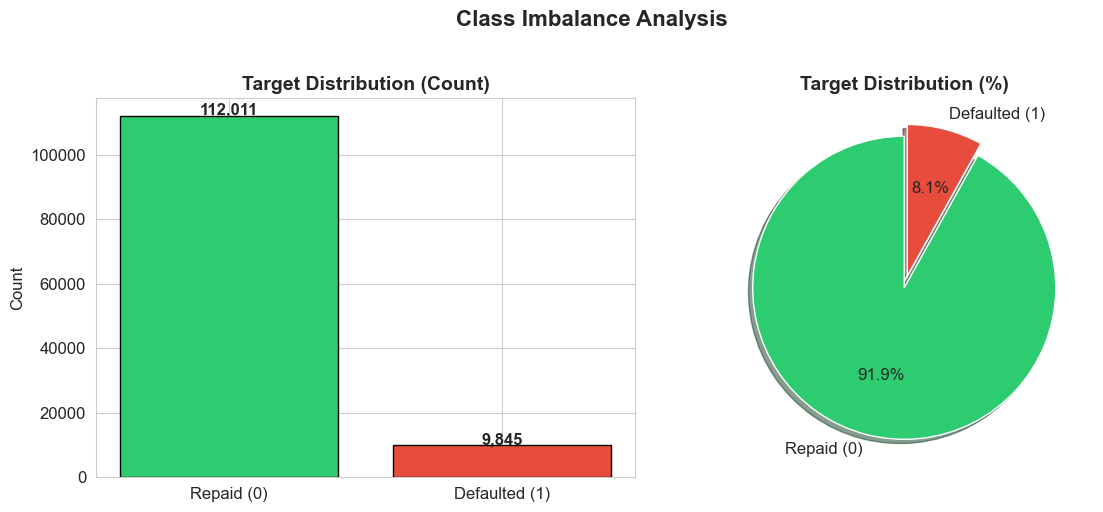

In [7]:
target_counts = df['Default'].value_counts()
target_pct = df['Default'].value_counts(normalize=True) * 100

print('=== Target Distribution ===')
for k in [0, 1]:
    print(f'  {k} ({"Repaid" if k==0 else "Defaulted"}): {target_counts[k]:,}  ({target_pct[k]:.2f}%)')

imbalance_ratio = target_counts[0] / target_counts[1]
print(f'\nImbalance ratio (0:1) = {imbalance_ratio:.1f}:1')
print('→ Significant class imbalance — SMOTE / class weighting required!')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['Repaid (0)', 'Defaulted (1)'], target_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Target Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(target_pct.values, labels=['Repaid (0)', 'Defaulted (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            explode=(0, 0.08), shadow=True)
axes[1].set_title('Target Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Missing Value Analysis

Columns with missing values: 33
                            Missing Count  Missing %
Own_House_Age                       80095    65.7300
Score_Source_1                      68835    56.4900
Social_Circle_Default               61928    50.8200
Client_Occupation                   41435    34.0000
Score_Source_3                      26922    22.0900
Credit_Bureau                       18540    15.2100
ID_Days                              5985     4.9100
Score_Source_2                       5686     4.6700
Population_Region_Relative           4868     3.9900
Loan_Annuity                         4826     3.9600
Client_Income_Type                   3701     3.0400
Client_Housing_Type                  3687     3.0300
Application_Process_Hour             3663     3.0100
Employed_Days                        3666     3.0100
Phone_Change                         3664     3.0100
House_Own                            3661     3.0000
Loan_Contract_Type                   3651     3.0000
Client_Educati

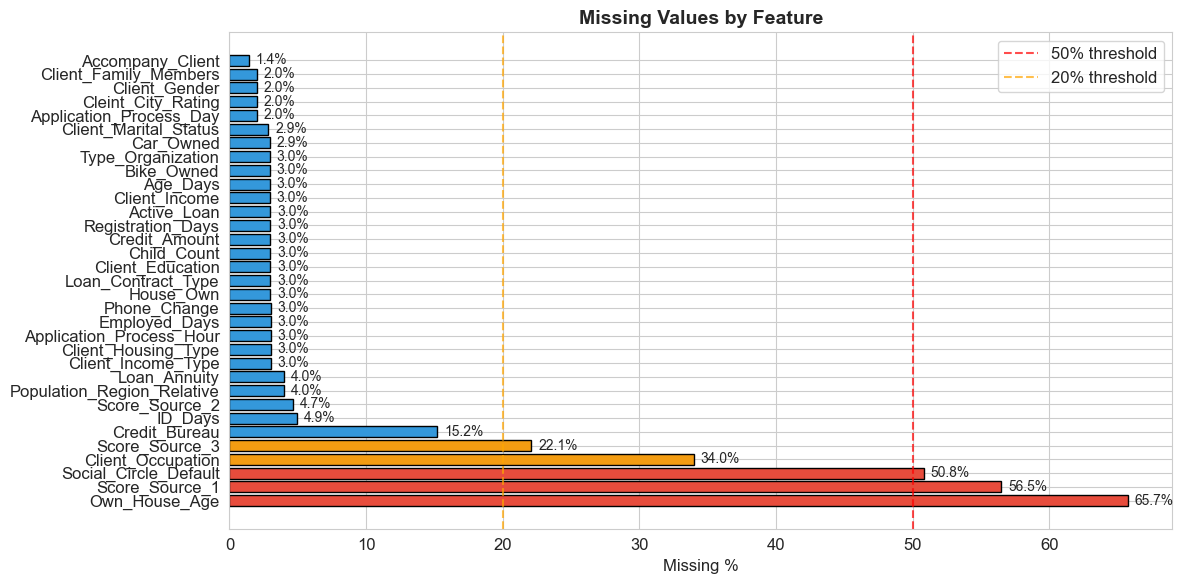

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
print(missing_df)

fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = ['#e74c3c' if p > 50 else '#f39c12' if p > 20 else '#3498db'
              for p in missing_df['Missing %']]
bars = ax.barh(missing_df.index, missing_df['Missing %'], color=colors_bar, edgecolor='black')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='20% threshold')
for bar, val in zip(bars, missing_df['Missing %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Numerical Feature Analysis

Numerical features: 27


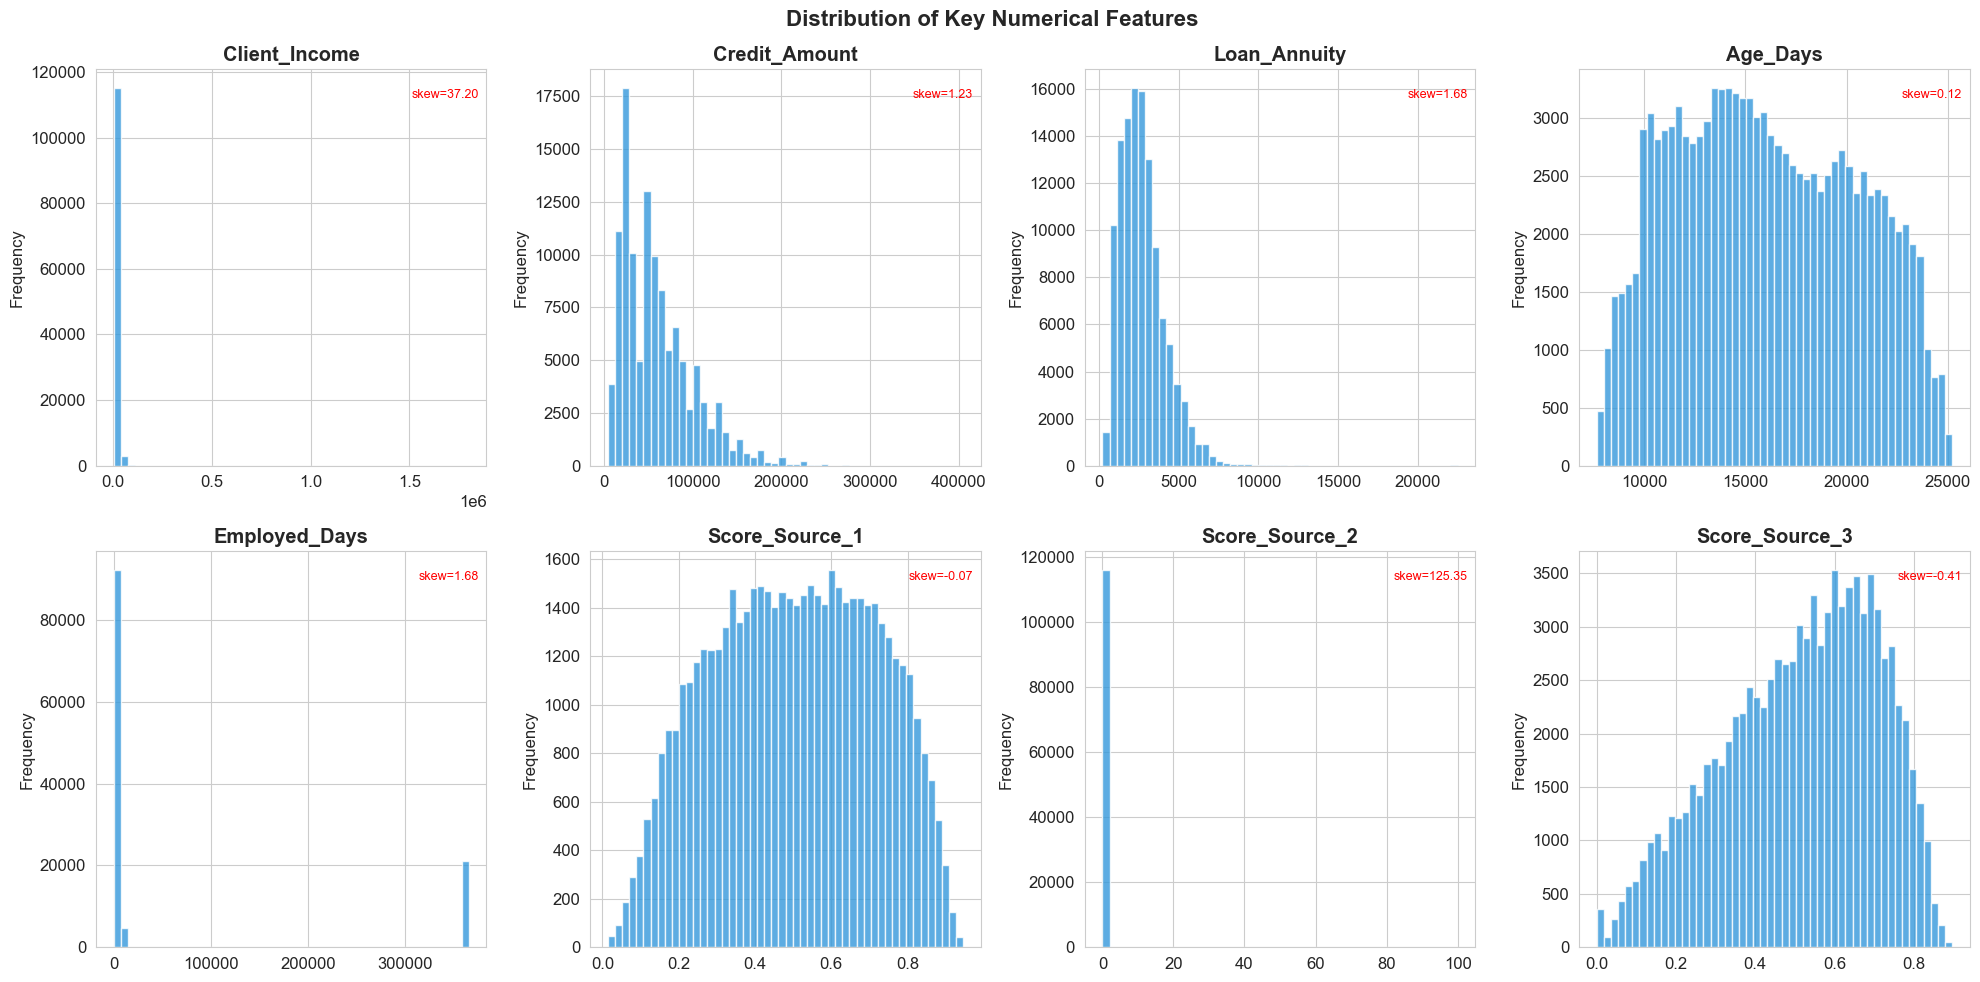

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['ID', 'Default']]
print(f'Numerical features: {len(num_cols)}')

# Distribution plots for key numeric features
key_numeric = ['Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Age_Days',
               'Employed_Days', 'Score_Source_1', 'Score_Source_2', 'Score_Source_3']
key_numeric = [c for c in key_numeric if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    data_clean = df[col].dropna()
    axes[i].hist(data_clean, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Frequency')
    skew = data_clean.skew()
    axes[i].text(0.98, 0.95, f'skew={skew:.2f}', transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=9, color='red')

plt.suptitle('Distribution of Key Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

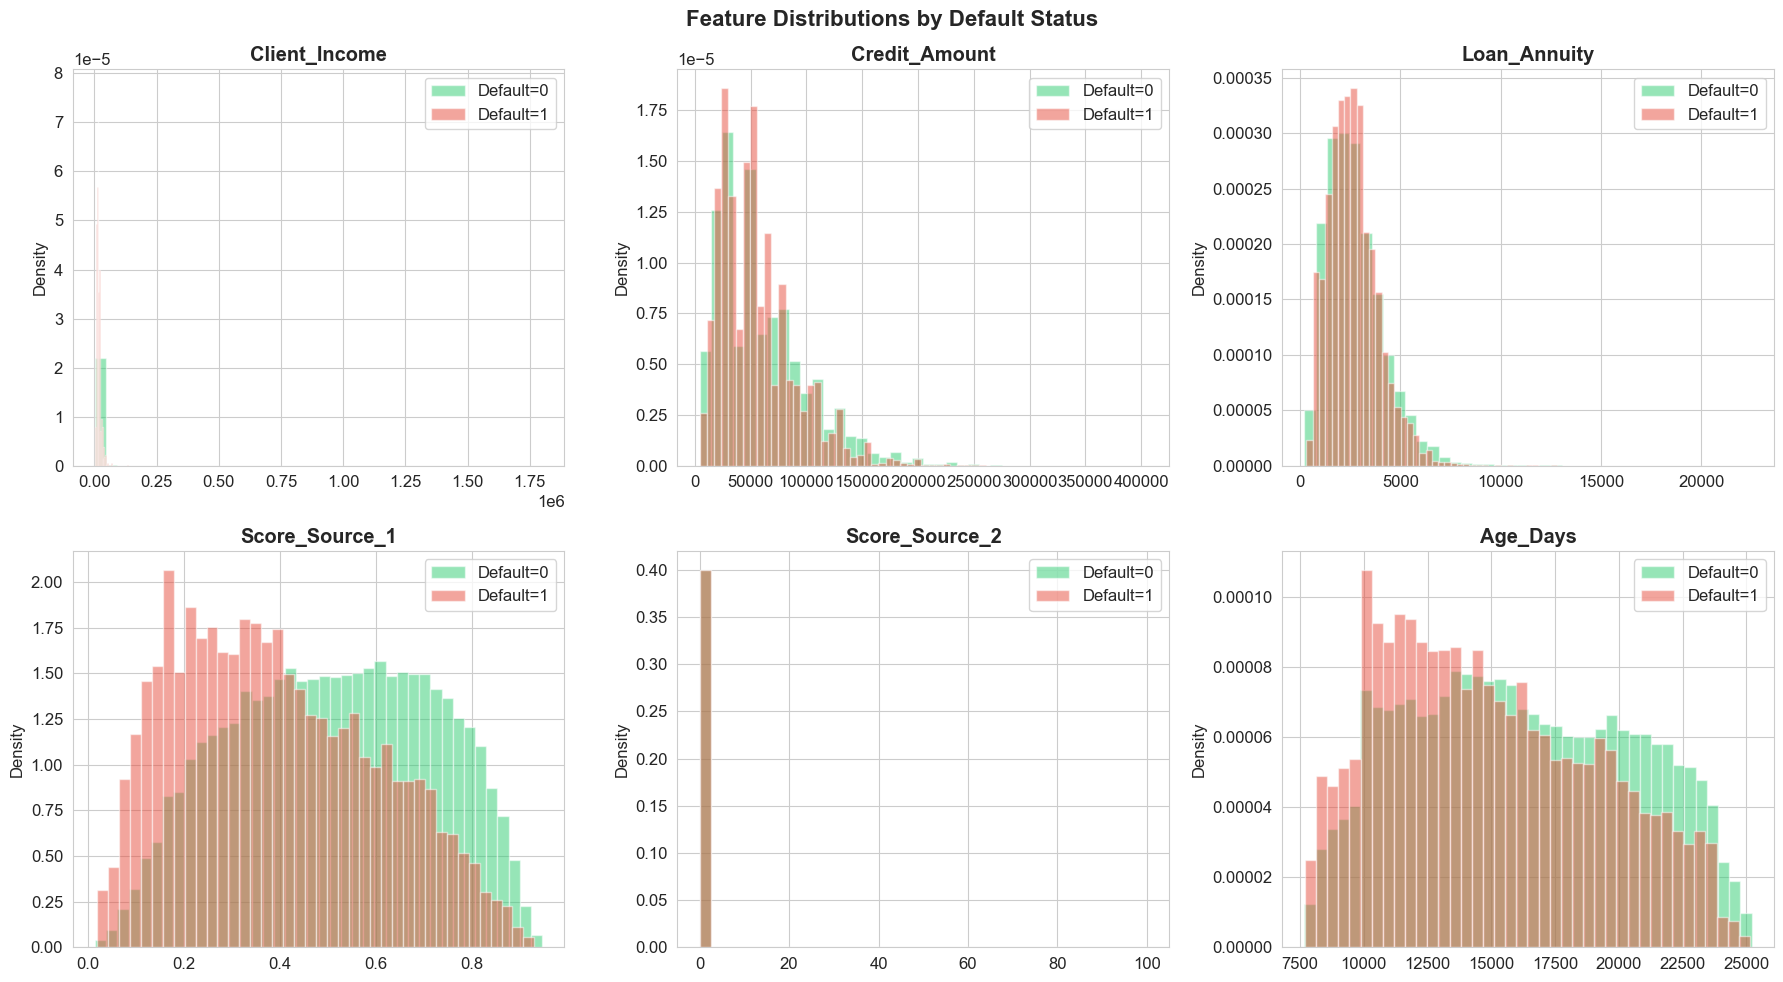

In [10]:
# Numerical features by Default class
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
compare_cols = ['Client_Income', 'Credit_Amount', 'Loan_Annuity',
                'Score_Source_1', 'Score_Source_2', 'Age_Days']
compare_cols = [c for c in compare_cols if c in df.columns]

for i, col in enumerate(compare_cols):
    for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
        data = df[df['Default'] == label][col].dropna()
        axes[i].hist(data, bins=40, alpha=0.5, color=color,
                     label=f'Default={label}', density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend()
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions by Default Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Categorical Feature Analysis

Categorical features: ['Accompany_Client', 'Client_Income_Type', 'Client_Education', 'Client_Marital_Status', 'Client_Gender', 'Loan_Contract_Type', 'Client_Housing_Type', 'Client_Occupation', 'Client_Permanent_Match_Tag', 'Client_Contact_Work_Tag', 'Type_Organization']


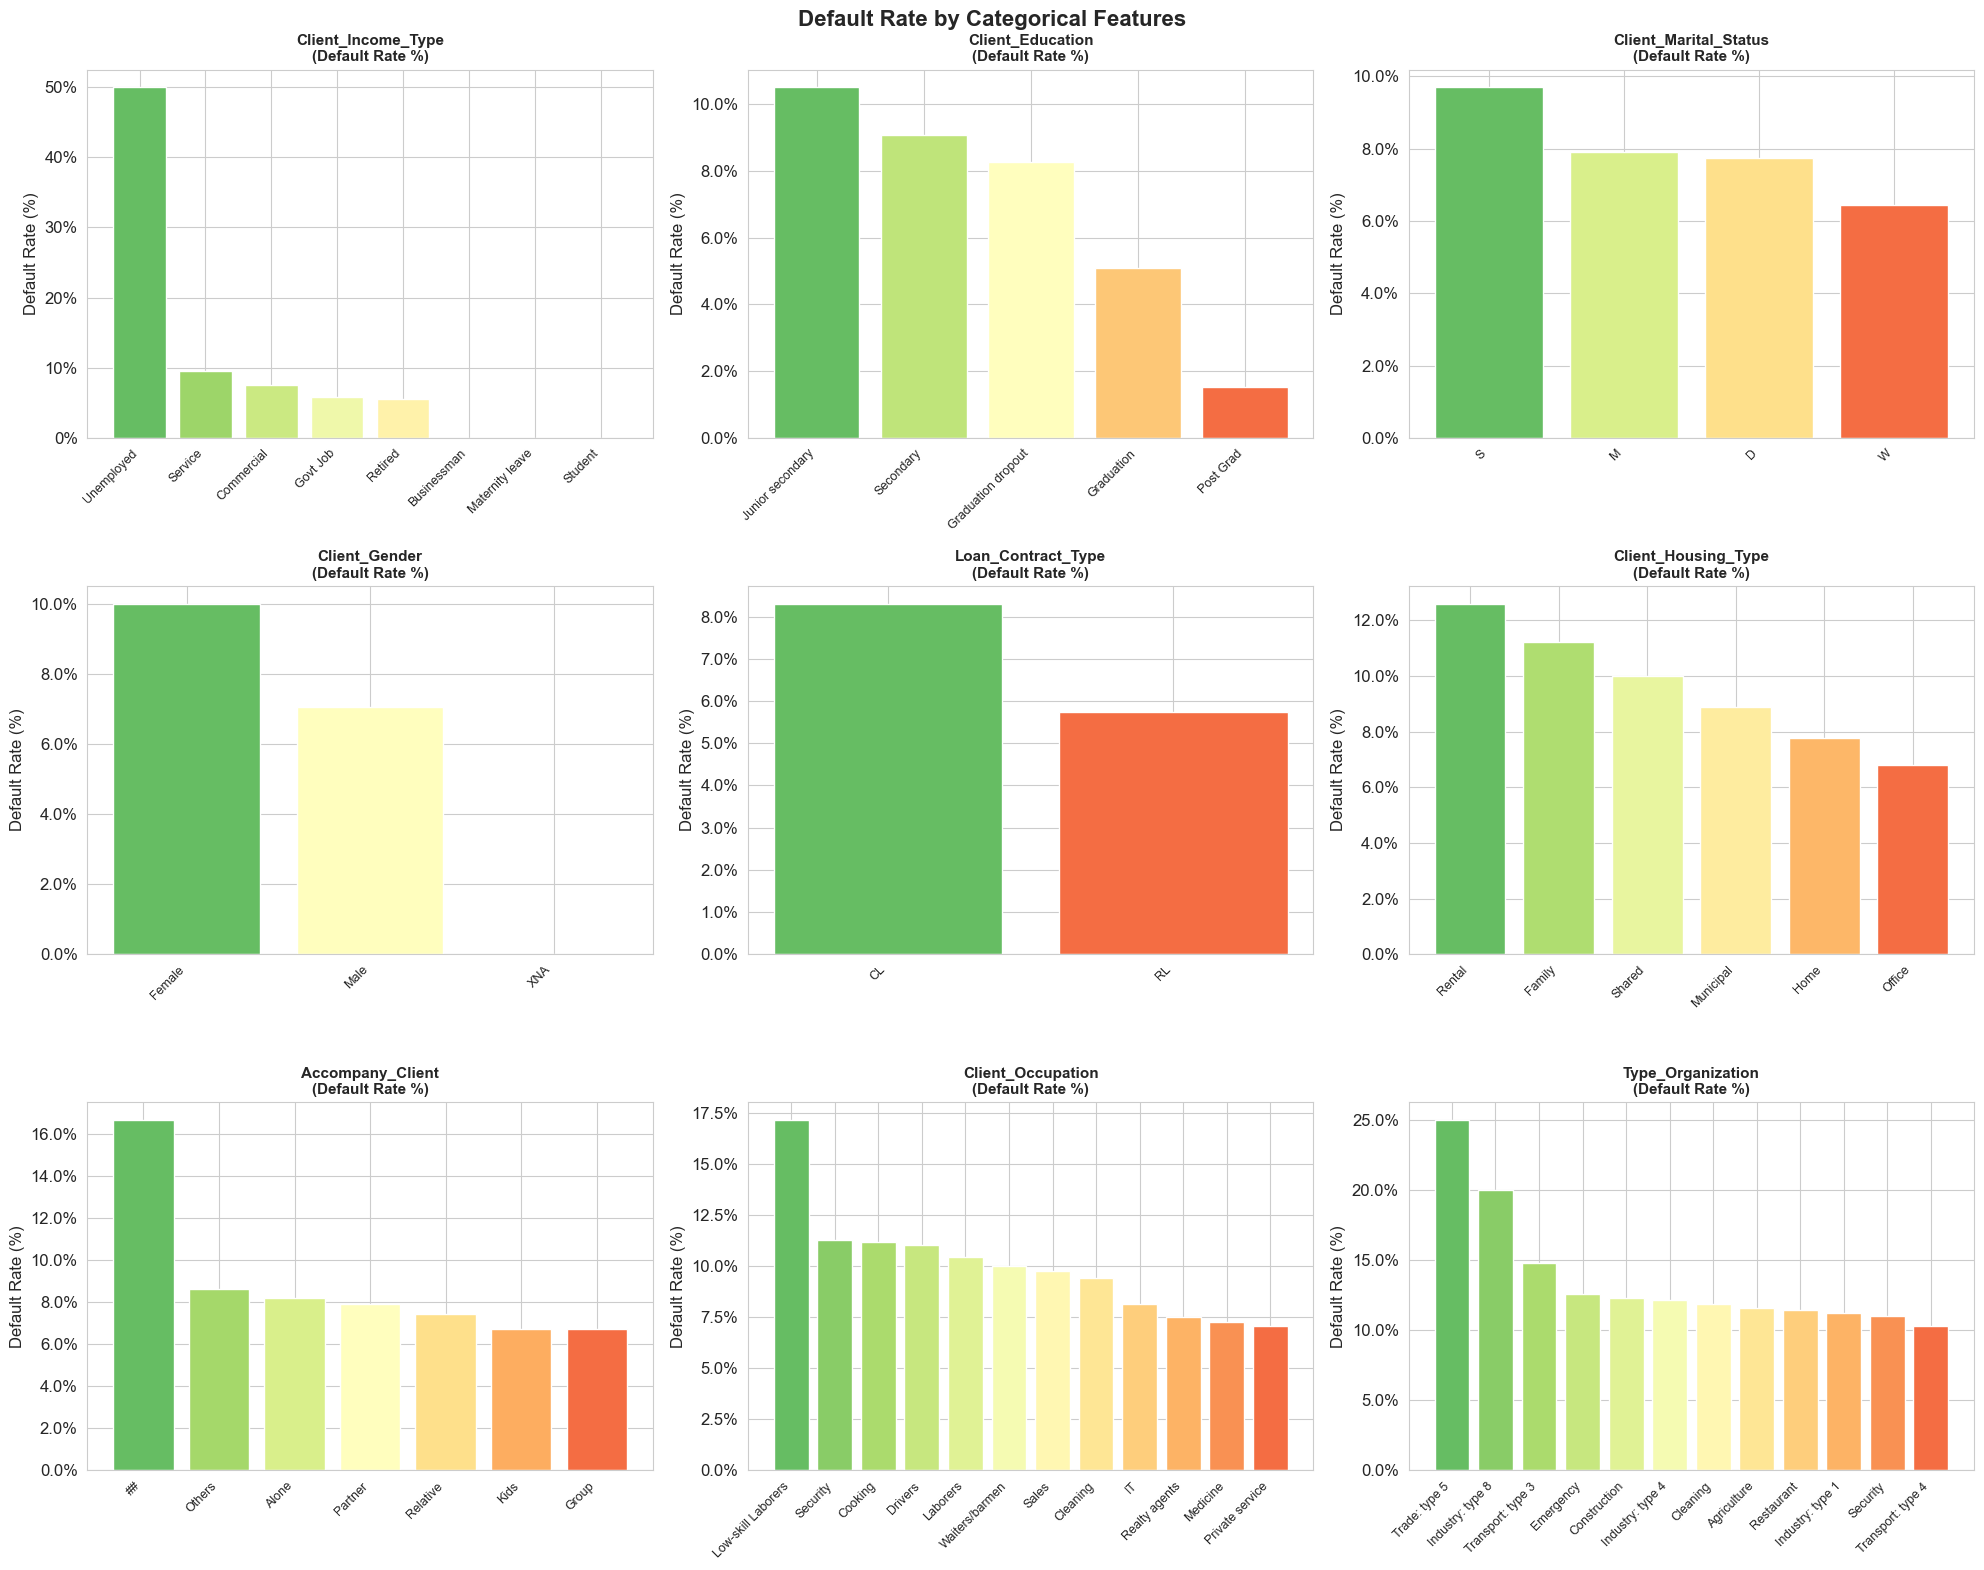

In [11]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical features: {cat_cols}')

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

plot_cat = ['Client_Income_Type', 'Client_Education', 'Client_Marital_Status',
            'Client_Gender', 'Loan_Contract_Type', 'Client_Housing_Type',
            'Accompany_Client', 'Client_Occupation', 'Type_Organization']
plot_cat = [c for c in plot_cat if c in df.columns]

for i, col in enumerate(plot_cat[:9]):
    # Default rate per category
    dr = df.groupby(col)['Default'].agg(['mean', 'count']).reset_index()
    dr.columns = [col, 'default_rate', 'count']
    dr = dr.sort_values('default_rate', ascending=False).head(12)
    
    colors_cat = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(dr)))
    axes[i].bar(range(len(dr)), dr['default_rate'] * 100, color=colors_cat)
    axes[i].set_xticks(range(len(dr)))
    axes[i].set_xticklabels(dr[col], rotation=45, ha='right', fontsize=9)
    axes[i].set_title(f'{col}\n(Default Rate %)', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('Default Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Outlier Detection

      Feature         Q1         Q3        IQR  Lower Fence  Upper Fence  N Outliers  Outlier %
Client_Income 11250.0000 20250.0000  9000.0000   -2250.0000   33750.0000        5392     4.4200
Credit_Amount 27000.0000 80865.0000 53865.0000  -53797.5000  161662.5000        2567     2.1100
 Loan_Annuity  1657.3500  3466.8000  1809.4500   -1056.8250    6180.9750        2894     2.3700
     Age_Days 12398.0000 19661.0000  7263.0000    1503.5000   30555.5000           0     0.0000
Employed_Days   932.0000  5634.0000  4702.0000   -6121.0000   12687.0000       21488    17.6300


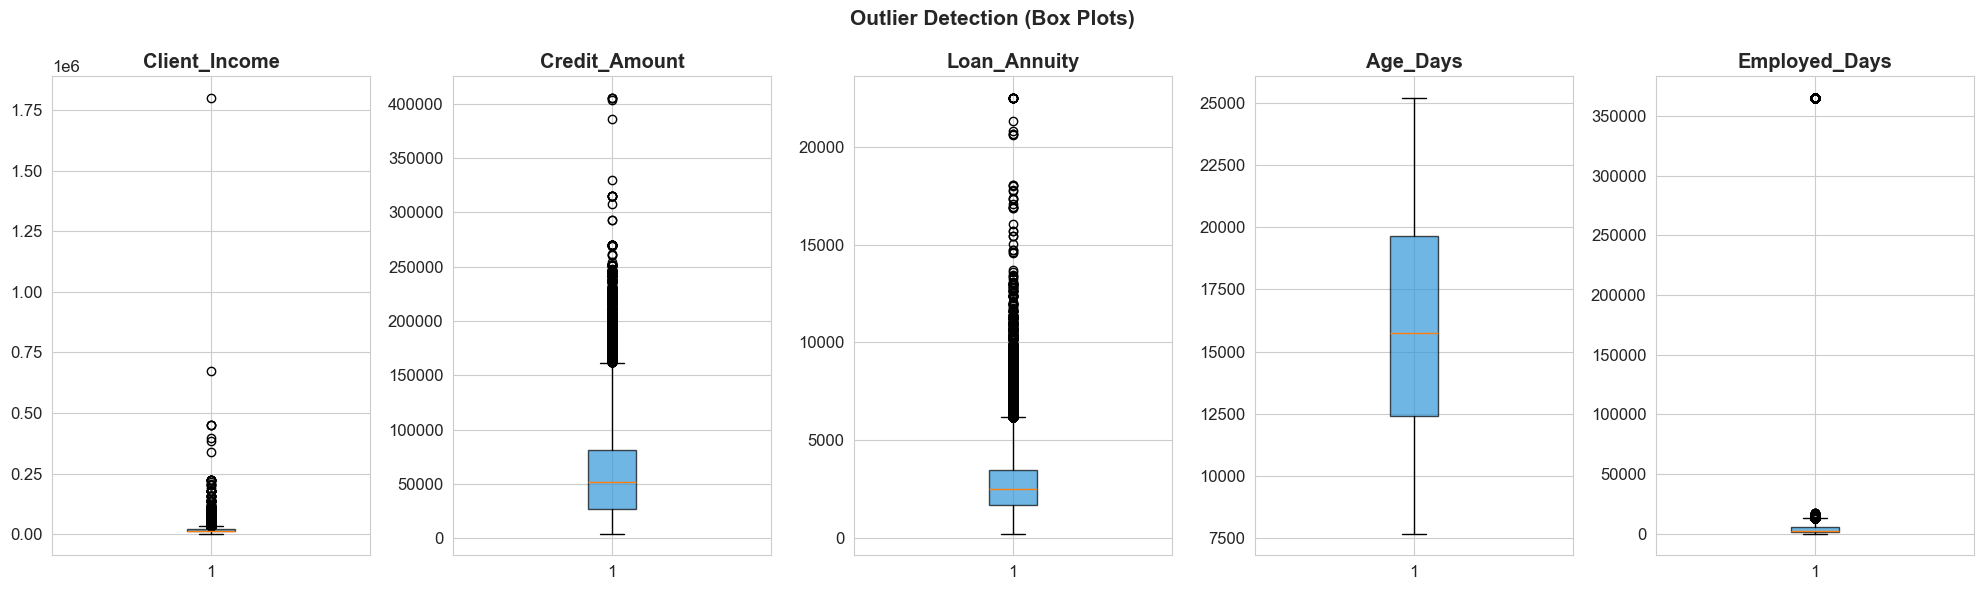

In [12]:
outlier_cols = ['Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Age_Days', 'Employed_Days']
outlier_cols = [c for c in outlier_cols if c in df.columns]

outlier_report = []
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({
        'Feature': col,
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Lower Fence': lower, 'Upper Fence': upper,
        'N Outliers': n_outliers,
        'Outlier %': round(n_outliers / len(df) * 100, 2)
    })

print(pd.DataFrame(outlier_report).to_string(index=False))

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(20, 6))
for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7))
    axes[i].set_title(col, fontweight='bold')

plt.suptitle('Outlier Detection (Box Plots)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

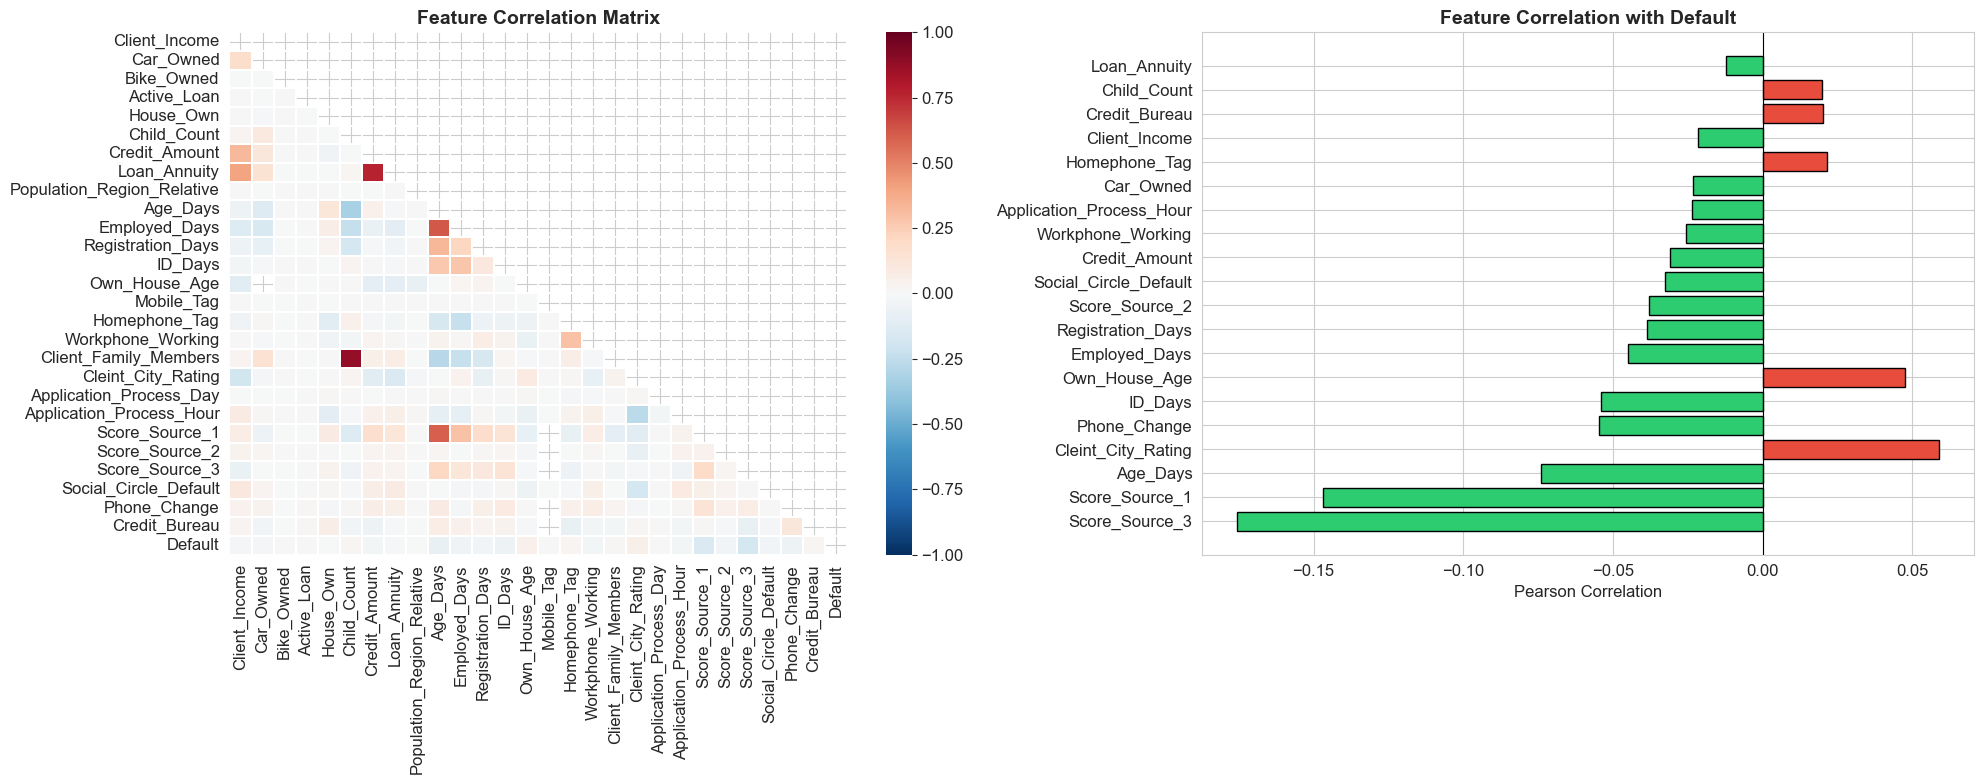

In [13]:
corr_cols = [c for c in num_cols if df[c].notna().sum() > len(df) * 0.3]
corr_matrix = df[corr_cols + ['Default']].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, ax=axes[0], linewidths=0.3, vmin=-1, vmax=1)
axes[0].set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)

# Correlation with target (top features)
target_corr = corr_matrix['Default'].drop('Default').sort_values(key=abs, ascending=False).head(20)
colors_bar = ['#e74c3c' if v > 0 else '#2ecc71' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='black')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Default', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

## 9. Feature vs Target — Key Relationships

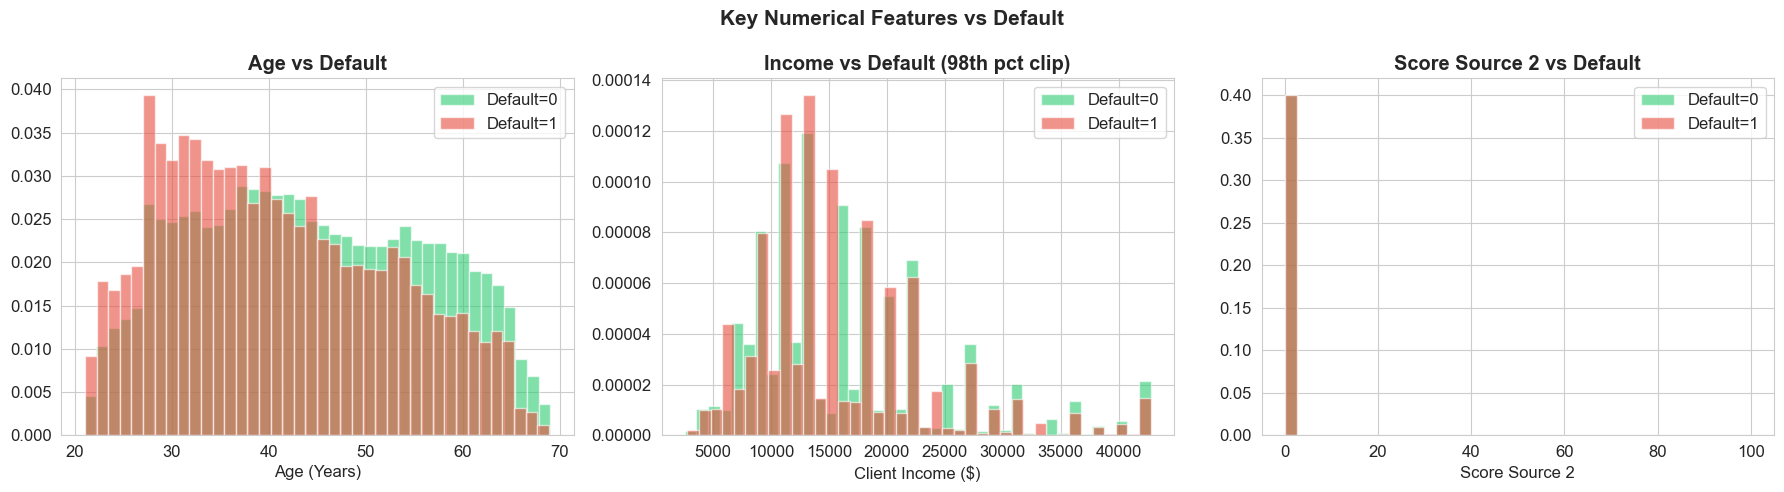

In [14]:
# Age distribution by default
df['Age_Years'] = df['Age_Days'].abs() / 365

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    axes[0].hist(df[df['Default']==label]['Age_Years'].dropna(), bins=40,
                 alpha=0.6, color=color, label=f'Default={label}', density=True)
axes[0].set_title('Age vs Default', fontweight='bold')
axes[0].set_xlabel('Age (Years)')
axes[0].legend()

# Income
income_clip = df['Client_Income'].clip(upper=df['Client_Income'].quantile(0.98))
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    axes[1].hist(income_clip[df['Default']==label].dropna(), bins=40,
                 alpha=0.6, color=color, label=f'Default={label}', density=True)
axes[1].set_title('Income vs Default (98th pct clip)', fontweight='bold')
axes[1].set_xlabel('Client Income ($)')
axes[1].legend()

# Score Source 2 (most complete)
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    axes[2].hist(df[df['Default']==label]['Score_Source_2'].dropna(), bins=40,
                 alpha=0.6, color=color, label=f'Default={label}', density=True)
axes[2].set_title('Score Source 2 vs Default', fontweight='bold')
axes[2].set_xlabel('Score Source 2')
axes[2].legend()

plt.suptitle('Key Numerical Features vs Default', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

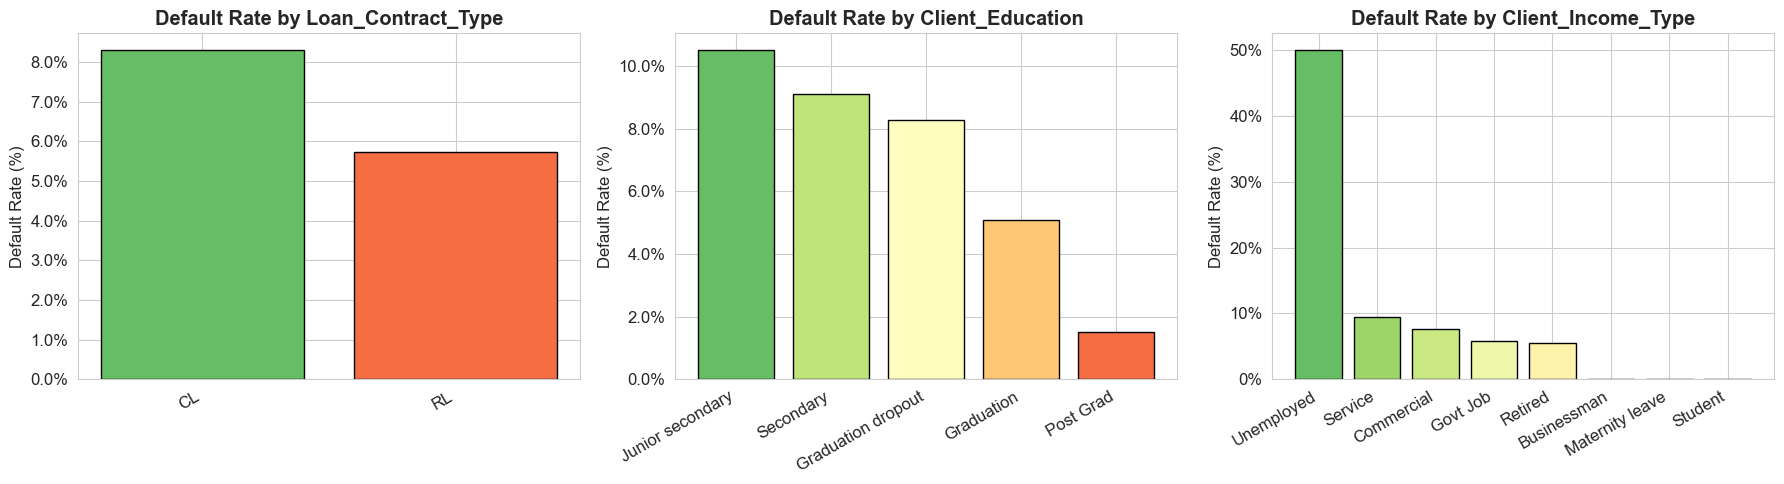

In [15]:
# Loan Contract Type × Default Rate
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['Loan_Contract_Type', 'Client_Education', 'Client_Income_Type']):
    dr = df.groupby(col)['Default'].mean().sort_values(ascending=False) * 100
    bar_colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(dr)))
    ax.bar(dr.index, dr.values, color=bar_colors, edgecolor='black')
    ax.set_title(f'Default Rate by {col}', fontweight='bold')
    ax.set_xticklabels(dr.index, rotation=30, ha='right')
    ax.set_ylabel('Default Rate (%)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

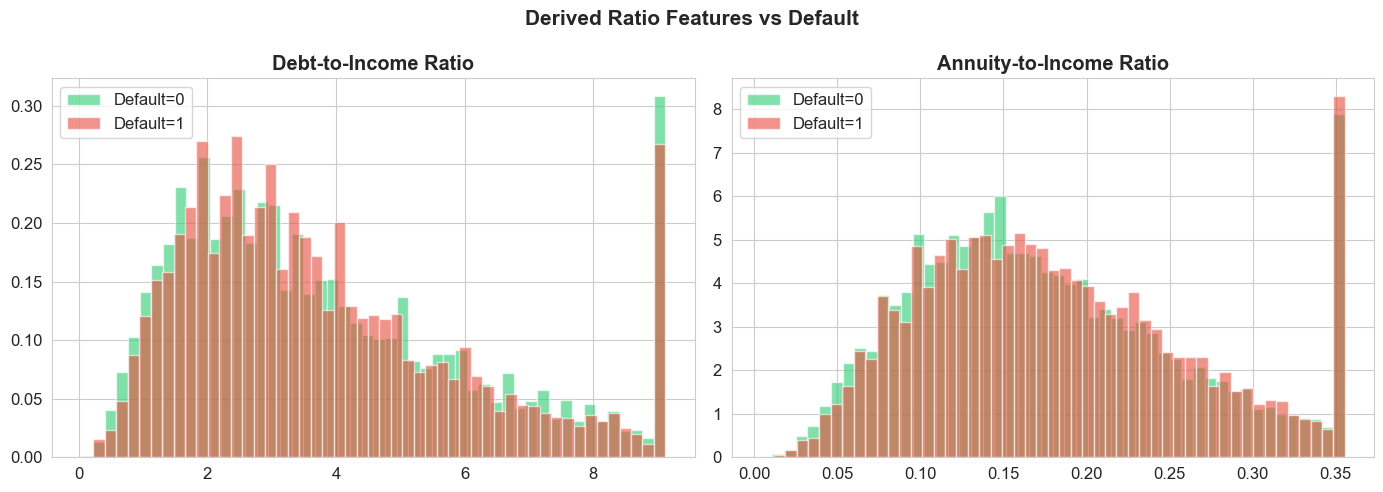

In [16]:
# Debt-to-income ratio analysis
df_clean = df.copy()
df_clean['Debt_Income_Ratio'] = df_clean['Credit_Amount'] / df_clean['Client_Income'].replace(0, np.nan)
df_clean['Annuity_Income_Ratio'] = df_clean['Loan_Annuity'] / df_clean['Client_Income'].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(
    axes,
    ['Debt_Income_Ratio', 'Annuity_Income_Ratio'],
    ['Debt-to-Income Ratio', 'Annuity-to-Income Ratio']
):
    clipped = df_clean[col].clip(upper=df_clean[col].quantile(0.95))
    for default_val, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
        mask = df_clean['Default'] == default_val
        ax.hist(clipped[mask].dropna(), bins=50, alpha=0.6, color=color,
                label=f'Default={default_val}', density=True)
    ax.set_title(label, fontweight='bold')
    ax.legend()

plt.suptitle('Derived Ratio Features vs Default', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Key Findings & Feature Engineering Plan

In [17]:
print('=' * 70)
print('EXPLORATORY DATA ANALYSIS — KEY FINDINGS')
print('=' * 70)

print(f'''
📊 DATASET SUMMARY
  • Total records       : {len(df):,}
  • Total features      : {df.shape[1]}
  • Default rate        : {df['Default'].mean():.2%}  (Significant imbalance!)
  • Imbalance ratio     : {(df['Default']==0).sum() / (df['Default']==1).sum():.1f} : 1

🔴 CLASS IMBALANCE
  • {(df['Default']==0).sum():,} non-defaults vs {(df['Default']==1).sum():,} defaults
  • Strategy: SMOTE for oversampling + scale_pos_weight in XGBoost
  • Evaluation metric: ROC-AUC + Average Precision (not plain accuracy!)

⚠️  MISSING VALUES (Top 5)
  • Own_House_Age        : {df['Own_House_Age'].isna().mean():.1%} (only house owners have this)
  • Score_Source_1       : {df['Score_Source_1'].isna().mean():.1%} (not always available)
  • Social_Circle_Default: {df['Social_Circle_Default'].isna().mean():.1%} 
  • Client_Occupation    : {df['Client_Occupation'].isna().mean():.1%}
  • Strategy: Median imputation for numerics, mode for categoricals

📈 KEY NUMERICAL INSIGHTS
  • Client_Income is highly right-skewed → log transform or RobustScaler
  • Employed_Days: negative values = days before application (use abs)
  • Age_Days: negative values → convert to positive years
  • Score_Source_2 has best coverage and separates classes well

📝 KEY CATEGORICAL INSIGHTS
  • Revolving Loans (RL) have higher default rate than Cash Loans (CL)
  • Lower education level correlates with higher default risk
  • Certain organization types show notably higher default rates

🔧 FEATURE ENGINEERING PLAN
  1. Age_Years           = abs(Age_Days) / 365
  2. Employed_Years      = abs(Employed_Days) / 365
  3. Debt_Income_Ratio   = Credit_Amount / Client_Income
  4. Annuity_Income_Ratio= Loan_Annuity / Client_Income
  5. Credit_Annuity_Ratio= Credit_Amount / Loan_Annuity
  6. Income_per_Member   = Client_Income / Client_Family_Members
  7. Score_Mean          = mean(Score_Source_1, 2, 3)
  8. Score_Std           = std(Score_Source_1, 2, 3)
  9. Phone_Reachability  = Mobile + Homephone + Workphone
 10. ID_Registration_Ratio = ID_Days / Registration_Days
''')

print('✅ EDA Complete. Proceed to model.py for training pipeline.')

EXPLORATORY DATA ANALYSIS — KEY FINDINGS

📊 DATASET SUMMARY
  • Total records       : 121,856
  • Total features      : 41
  • Default rate        : 8.08%  (Significant imbalance!)
  • Imbalance ratio     : 11.4 : 1

🔴 CLASS IMBALANCE
  • 112,011 non-defaults vs 9,845 defaults
  • Strategy: SMOTE for oversampling + scale_pos_weight in XGBoost
  • Evaluation metric: ROC-AUC + Average Precision (not plain accuracy!)

⚠️  MISSING VALUES (Top 5)
  • Own_House_Age        : 65.7% (only house owners have this)
  • Score_Source_1       : 56.5% (not always available)
  • Social_Circle_Default: 50.8% 
  • Client_Occupation    : 34.0%
  • Strategy: Median imputation for numerics, mode for categoricals

📈 KEY NUMERICAL INSIGHTS
  • Client_Income is highly right-skewed → log transform or RobustScaler
  • Employed_Days: negative values = days before application (use abs)
  • Age_Days: negative values → convert to positive years
  • Score_Source_2 has best coverage and separates classes well

📝 KEY C